# Stage 2 — Dental Disease Classifier (v6)

## Why v6 replaces v5

v5 trained a **Faster R-CNN detector** on DENTEX tooth crops with 4 disease classes
(Caries, Deep Caries, Periapical Lesion, Impacted). "Healthy" was never an explicit
class — a tooth was only called healthy by *absence* of a detection above threshold.
That means a missed/low-confidence detection on a genuinely diseased tooth silently
became "Healthy" with zero supporting evidence — there was no real disease-vs-healthy
decision being made per tooth.

**v6 fixes this with an explicit 5-class classifier:**

```
0 = Healthy
1 = Caries
2 = Deep Caries
3 = Periapical Lesion
4 = Impacted
```

## Where do "Healthy" crops come from?

DENTEX's `quadrant-enumeration-disease` annotation file **only contains annotations
for diseased teeth** — healthy teeth have zero annotations in that file at all. The
sibling `quadrant-enumeration` (healthy-inclusive) DENTEX subset is a **different,
only-partially-overlapping pool of 634 images** (vs. 705 disease-training images),
so we can't safely assume image-id alignment between the two files.

Instead, v6 derives Healthy crops **from the same 705 disease-training images**,
using your own trained **Stage 1 Mask R-CNN** to detect every tooth in each image,
then keeping any detected tooth box that does **not** overlap a disease annotation
above a small IoU threshold. This guarantees Healthy and Diseased crops come from
the exact same images/domain — no cross-dataset alignment risk, and it reuses a
model you already trained instead of needing a new Kaggle dataset.

(If you'd rather have an independent, larger pool of confirmed-healthy crops, the
Tufts Dental Database on Kaggle is a reasonable secondary source — but the
in-domain derivation below is the more defensible default.)

## Cell map

| Cell | Purpose |
|------|---------|
| 1 | Setup: imports, paths (with fallback discovery), config |
| 2 | Load Stage 1 Mask R-CNN (needed to derive Healthy crops) |
| 3 | Parse DENTEX disease annotations → class map |
| 4 | Derive Healthy crops via Stage 1 + IoU subtraction |
| 5 | Dataset class, train/val/test split (by image, no leakage) |
| 6 | Model: ResNet-34 5-way classifier |
| 7 | Training loop (class-weighted, early stopping) |
| 8 | Test set evaluation (precision/recall/F1, confusion matrix) |
| 9 | Save final artifacts + quick inference sanity check |


In [2]:
# ================== CELL 1: SETUP ==================
import os, json, random, copy, time
import numpy as np
import cv2
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import torch
import torch.nn as nn
import torchvision
import torchvision.transforms.functional as TF
from torchvision import transforms as T
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor
from torchvision.ops import nms
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torch.nn.functional as F

from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score

print('='*70)
print('[CELL 1] STAGE 2 v6 — SETUP')
print('='*70)
print(f'  PyTorch:     {torch.__version__}')
print(f'  Torchvision: {torchvision.__version__}')
print(f'  CUDA:        {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'  GPU:         {torch.cuda.get_device_name(0)}')

# ── Stage 1 weights (needed in THIS notebook to derive Healthy crops) ──────
# Attach the Stage 1 training notebook's output as a Kaggle dataset input.
STAGE1_WEIGHTS_CANDIDATES = [
    '/kaggle/input/datasets/ethelrani/maskrcnn-teeth-stage1-weights/maskrcnn_teeth_best.pth',
    '/kaggle/input/maskrcnn-teeth-stage1-weights/maskrcnn_teeth_best.pth',
]

# ── DENTEX dataset (same Kaggle dataset already used by v5) ────────────────
DENTEX_ROOT_CANDIDATES = [
    '/kaggle/input/datasets/truthisneverlinear/dentex-challenge-2023',
    '/kaggle/input/dentex-challenge-2023',
]

def first_existing(candidates, must_exist=True):
    for c in candidates:
        if os.path.exists(c):
            return c
    return candidates[0] if not must_exist else None

STAGE1_WEIGHTS = first_existing(STAGE1_WEIGHTS_CANDIDATES)
DENTEX_ROOT    = first_existing(DENTEX_ROOT_CANDIDATES)

print()
print('[CELL 1] Path discovery:')
print(f'  STAGE1_WEIGHTS candidates tried: {STAGE1_WEIGHTS_CANDIDATES}')
print(f'  STAGE1_WEIGHTS resolved to     : {STAGE1_WEIGHTS}')
print(f'  DENTEX_ROOT candidates tried   : {DENTEX_ROOT_CANDIDATES}')
print(f'  DENTEX_ROOT resolved to        : {DENTEX_ROOT}')

if DENTEX_ROOT is None:
    raise FileNotFoundError(
        '❌ DENTEX dataset root not found. Attach the dataset '
        '"truthisneverlinear/dentex-challenge-2023" to this notebook.'
    )

# Disease-labelled training subset (same files v5 used)
_disease_dir_candidates = [
    os.path.join(DENTEX_ROOT, 'training_data/training_data/quadrant-enumeration-disease'),
    os.path.join(DENTEX_ROOT, 'training_data/quadrant-enumeration-disease'),
    os.path.join(DENTEX_ROOT, 'training_data/training_data/quadrant_enumeration_disease'),
]
DENTEX_DISEASE_DIR = first_existing(_disease_dir_candidates)

_ann_file_candidates = []
if DENTEX_DISEASE_DIR:
    _ann_file_candidates = [
        os.path.join(DENTEX_DISEASE_DIR, 'train_quadrant_enumeration_disease.json'),
        os.path.join(DENTEX_DISEASE_DIR, 'quadrant_enumeration_disease.json'),
    ]
DENTEX_ANN_FILE = first_existing(_ann_file_candidates)

_img_dir_candidates = []
if DENTEX_DISEASE_DIR:
    _img_dir_candidates = [
        os.path.join(DENTEX_DISEASE_DIR, 'xrays'),
        DENTEX_DISEASE_DIR,
    ]
DENTEX_IMG_DIR = first_existing(_img_dir_candidates)

print()
print('[CELL 1] DENTEX path checks:')
for label, path in [
    ('Stage1 weights   ', STAGE1_WEIGHTS),
    ('DENTEX disease dir', DENTEX_DISEASE_DIR),
    ('DENTEX train JSON ', DENTEX_ANN_FILE),
    ('DENTEX images dir ', DENTEX_IMG_DIR),
]:
    status = '✓' if (path and os.path.exists(path)) else '✗ MISSING'
    print(f'  {status}  {label}: {path}')

if not (DENTEX_ANN_FILE and os.path.exists(DENTEX_ANN_FILE)):
    raise FileNotFoundError(
        '❌ Could not locate train_quadrant_enumeration_disease.json. '
        'Print os.walk(DENTEX_ROOT) below and add the real path to '
        '_ann_file_candidates above.'
    )
if not (STAGE1_WEIGHTS and os.path.exists(STAGE1_WEIGHTS)):
    print('  ⚠  Stage 1 weights not found yet — Cell 4 (Healthy-crop derivation) '
          'will fail until you attach the Stage 1 weights dataset.')

CONFIG2 = {
    'batch_size':         16,
    'lr':                 1e-4,
    'epochs':             40,
    'img_size':           224,
    'crop_pad':            15,    # px padding around every tooth crop (disease AND healthy)
    'train_ratio':        0.70,
    'val_ratio':           0.15,
    'num_workers':         2,
    'patience':            8,     # early stopping (epochs with no val macro-F1 improvement)
    'weight_decay':        1e-3,  # was 1e-4 — raised to fight overfitting
    'dropout':             0.5,   # was 0.3 — raised to fight overfitting
    'freeze_early_layers': True,  # freeze conv1/bn1/layer1 of ResNet-34
    'focal_gamma':         2.0,   # focal loss focusing parameter
    'minority_frac_thresh': 0.20, # disease classes with train count < this fraction of the
                                   # largest disease class get heavier augmentation
    'stage1_conf':         0.6,   # confidence threshold for Stage 1 tooth detection
    'stage1_nms_iou':      0.3,
    'healthy_iou_thresh':  0.10,  # max overlap with a disease box to still call a tooth "Healthy"
    'healthy_cap_ratio':   4.0,   # cap Healthy count at N x the largest disease class count
    'seed':                42,
}
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
random.seed(CONFIG2['seed']); np.random.seed(CONFIG2['seed']); torch.manual_seed(CONFIG2['seed'])

print()
print(f'[CELL 1] CONFIG2 = {json.dumps(CONFIG2, indent=2)}')
print(f'[CELL 1] ✓ Device: {DEVICE}')
print('[CELL 1] ✓ Setup complete.')


[CELL 1] STAGE 2 v6 — SETUP
  PyTorch:     2.10.0+cu128
  Torchvision: 0.25.0+cu128
  CUDA:        True
  GPU:         Tesla T4

[CELL 1] Path discovery:
  STAGE1_WEIGHTS candidates tried: ['/kaggle/input/datasets/ethelrani/maskrcnn-teeth-stage1-weights/maskrcnn_teeth_best.pth', '/kaggle/input/maskrcnn-teeth-stage1-weights/maskrcnn_teeth_best.pth']
  STAGE1_WEIGHTS resolved to     : /kaggle/input/datasets/ethelrani/maskrcnn-teeth-stage1-weights/maskrcnn_teeth_best.pth
  DENTEX_ROOT candidates tried   : ['/kaggle/input/datasets/truthisneverlinear/dentex-challenge-2023', '/kaggle/input/dentex-challenge-2023']
  DENTEX_ROOT resolved to        : /kaggle/input/datasets/truthisneverlinear/dentex-challenge-2023

[CELL 1] DENTEX path checks:
  ✓  Stage1 weights   : /kaggle/input/datasets/ethelrani/maskrcnn-teeth-stage1-weights/maskrcnn_teeth_best.pth
  ✓  DENTEX disease dir: /kaggle/input/datasets/truthisneverlinear/dentex-challenge-2023/training_data/training_data/quadrant-enumeration-disease

In [3]:
# ================== CELL 2: LOAD STAGE 1 MODEL ==================
# Needed only to derive Healthy tooth crops in Cell 4. Stage 1 itself is NOT
# being retrained or modified here.

def get_stage1_model(num_classes=33):
    model = torchvision.models.detection.maskrcnn_resnet50_fpn(weights=None)
    in_feat = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_feat, num_classes)
    in_feat_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
    model.roi_heads.mask_predictor = MaskRCNNPredictor(in_feat_mask, 256, num_classes)
    return model

print('[CELL 2] Building Stage 1 Mask R-CNN architecture (33 classes)...')
stage1_model = get_stage1_model(num_classes=33)

if STAGE1_WEIGHTS and os.path.exists(STAGE1_WEIGHTS):
    ckpt1 = torch.load(STAGE1_WEIGHTS, map_location=DEVICE)
    if isinstance(ckpt1, dict) and 'model_state_dict' in ckpt1:
        missing, unexpected = stage1_model.load_state_dict(ckpt1['model_state_dict'], strict=False).missing_keys, \
                               stage1_model.load_state_dict(ckpt1['model_state_dict'], strict=False).unexpected_keys
        print(f'  Loaded from model_state_dict. val_loss at save time: {ckpt1.get("val_loss", "N/A")}')
    else:
        stage1_model.load_state_dict(ckpt1, strict=False)
        print('  Loaded from raw state_dict (no metadata wrapper found).')
    stage1_model.to(DEVICE).eval()
    n_params = sum(p.numel() for p in stage1_model.parameters())
    print(f'  ✓ Stage 1 loaded. Total params: {n_params:,}')
else:
    raise FileNotFoundError(
        '❌ Stage 1 weights missing — cannot derive Healthy crops without it. '
        'Attach the Stage 1 weights dataset and re-run Cell 1.'
    )

def stage1_infer(img_tensor, conf=CONFIG2['stage1_conf'], iou_thr=CONFIG2['stage1_nms_iou']):
    '''Run Stage 1 on one image tensor (C,H,W in [0,1]). Returns boxes only (xyxy, numpy).'''
    with torch.no_grad():
        raw = stage1_model([img_tensor.to(DEVICE)])[0]
    keep = raw['scores'] >= conf
    filt = {k: v[keep] for k, v in raw.items()}
    if len(filt['boxes']) > 0:
        idx = nms(filt['boxes'], filt['scores'], iou_thr)
        filt = {k: v[idx] for k, v in filt.items()}
    return filt['boxes'].cpu().numpy()

print('[CELL 2] ✓ stage1_infer() helper ready.')

# ── GPU smoke test: catch kernel-image mismatches before the slow Cell 4 loop ──
print('[CELL 2] Running GPU smoke test (tiny dummy forward pass)...')
try:
    _dummy = torch.rand(3, 64, 64)
    with torch.no_grad():
        _ = stage1_model([_dummy.to(DEVICE)])
    print(f'  ✓ Smoke test passed on {DEVICE}.')
except RuntimeError as e:
    print(f'  ✗ Smoke test FAILED on {DEVICE}: {e}')
    if DEVICE.type == 'cuda':
        print('  This usually means the installed torch/cu12x wheel has no compiled '
              "kernels for this GPU's architecture (e.g. P100/Pascal, sm_60).")
        print('  ACTION: In Kaggle, go to Settings -> Accelerator and switch to '
              '"GPU T4 x2" (what Stage 1 was trained on), then re-run from Cell 1.')
        print('  Falling back to CPU for this session so you can at least keep debugging...')
        DEVICE = torch.device('cpu')
        stage1_model.to(DEVICE)
        with torch.no_grad():
            _ = stage1_model([_dummy.to(DEVICE)])
        print(f'  ✓ CPU fallback confirmed working. NOTE: Cell 4 will be slow on CPU '
              f'(~705 images) -- switching accelerator is strongly recommended instead.')
    else:
        raise


[CELL 2] Building Stage 1 Mask R-CNN architecture (33 classes)...
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 172MB/s]


  Loaded from model_state_dict. val_loss at save time: 0.8633273992273542
  ✓ Stage 1 loaded. Total params: 44,089,237
[CELL 2] ✓ stage1_infer() helper ready.
[CELL 2] Running GPU smoke test (tiny dummy forward pass)...
  ✓ Smoke test passed on cuda.


In [4]:
# ================== CELL 3: PARSE DENTEX DISEASE ANNOTATIONS ==================
print('[CELL 3] Loading DENTEX disease annotation JSON...')
with open(DENTEX_ANN_FILE) as f:
    _raw = json.load(f)

print(f'  Top-level keys     : {list(_raw.keys())}')
_images = _raw.get('images', [])
_anns   = _raw.get('annotations', [])
_cats3  = _raw.get('categories_3', [])
print(f'  images             : {len(_images)} entries')
print(f'  annotations        : {len(_anns)} entries')
print(f'  categories_3 (raw) : {_cats3}')

# Build disease class map. Label 0 is reserved for Healthy (derived in Cell 4).
_COLOR_POOL = {
    'Healthy':           (0,   220, 100),
    'Caries':            (255,  50,  50),
    'Deep Caries':       (200,   0, 200),
    'Periapical Lesion': (255, 200,   0),
    'Impacted':          (255, 100,   0),
}

if _cats3:
    _sorted_cats = sorted(_cats3, key=lambda c: c['id'])
else:
    print('  ⚠  No categories_3 key found — falling back to known DENTEX disease ids.')
    _ids3 = sorted(set(a.get('category_id_3', -1) for a in _anns if 'category_id_3' in a))
    _DENTEX_KNOWN = {0: 'Impacted', 1: 'Caries', 2: 'Periapical Lesion', 3: 'Deep Caries'}
    _sorted_cats = [{'id': i, 'name': _DENTEX_KNOWN.get(i, f'disease_{i}')} for i in _ids3]

CLASSES = {0: 'Healthy'}
CAT3_REMAP = {}   # original DENTEX category_id_3 -> final 1..4 class label
for new_label, cat in enumerate(_sorted_cats, start=1):
    CLASSES[new_label] = cat['name']
    CAT3_REMAP[cat['id']] = new_label

NUM_CLASSES = len(CLASSES)
print(f'  ✓ CLASSES     : {CLASSES}')
print(f'  ✓ CAT3_REMAP  : {CAT3_REMAP}')
print(f'  NUM_CLASSES = {NUM_CLASSES}  (1 Healthy + {NUM_CLASSES-1} disease classes)')

CLASS_COLORS = {name: _COLOR_POOL.get(name, (128, 128, 255)) for name in CLASSES.values()}

# image_id -> file path, with existence check
_id_to_file = {img['id']: img['file_name'] for img in _images}
_id_to_path = {}
_missing_files = 0
for iid, fname in _id_to_file.items():
    fpath = os.path.join(DENTEX_IMG_DIR, fname)
    if os.path.exists(fpath):
        _id_to_path[iid] = fpath
    else:
        _missing_files += 1
print(f'  Images resolved to disk : {len(_id_to_path)} / {len(_id_to_file)}  '
      f'(missing: {_missing_files})')

# image_id -> list of disease boxes [{box: xyxy, label: int}, ...]
DISEASE_BOXES_BY_IMAGE = {}
_disease_samples = []   # flat list: {'fpath', 'box'(xyxy), 'label', 'image_id'}
_skipped_unmapped = 0
_skipped_tiny = 0
_skipped_missing_img = 0

for ann in _anns:
    orig_cid = ann.get('category_id_3', -1)
    lbl = CAT3_REMAP.get(orig_cid)
    if lbl is None:
        _skipped_unmapped += 1
        continue
    iid = ann['image_id']
    if iid not in _id_to_path:
        _skipped_missing_img += 1
        continue
    x, y, w, h = ann['bbox']
    if w < 4 or h < 4:
        _skipped_tiny += 1
        continue
    box = (float(x), float(y), float(x + w), float(y + h))
    DISEASE_BOXES_BY_IMAGE.setdefault(iid, []).append(box)
    _disease_samples.append({'fpath': _id_to_path[iid], 'box': box, 'label': lbl, 'image_id': iid})

print()
print('[CELL 3] Disease annotation parsing summary:')
print(f'  Total annotations         : {len(_anns)}')
print(f'  Mapped to a disease class : {len(_disease_samples)}')
print(f'  Skipped (unmapped cat_id) : {_skipped_unmapped}')
print(f'  Skipped (missing image)  : {_skipped_missing_img}')
print(f'  Skipped (box too tiny)   : {_skipped_tiny}')

from collections import Counter
_disease_counts = Counter(s['label'] for s in _disease_samples)
print()
print('  Per-class disease sample counts (pre-Healthy-derivation):')
for lbl in sorted(_disease_counts):
    print(f'    [{lbl}] {CLASSES[lbl]:<20s}: {_disease_counts[lbl]}')

print('[CELL 3] ✓ Disease annotations parsed.')


[CELL 3] Loading DENTEX disease annotation JSON...
  Top-level keys     : ['images', 'annotations', 'categories_1', 'categories_2', 'categories_3']
  images             : 705 entries
  annotations        : 3529 entries
  categories_3 (raw) : [{'id': 0, 'name': 'Impacted', 'supercategory': 'Impacted'}, {'id': 1, 'name': 'Caries', 'supercategory': 'Caries'}, {'id': 2, 'name': 'Periapical Lesion', 'supercategory': 'Periapical Lesion'}, {'id': 3, 'name': 'Deep Caries', 'supercategory': 'Deep Caries'}]
  ✓ CLASSES     : {0: 'Healthy', 1: 'Impacted', 2: 'Caries', 3: 'Periapical Lesion', 4: 'Deep Caries'}
  ✓ CAT3_REMAP  : {0: 1, 1: 2, 2: 3, 3: 4}
  NUM_CLASSES = 5  (1 Healthy + 4 disease classes)
  Images resolved to disk : 705 / 705  (missing: 0)

[CELL 3] Disease annotation parsing summary:
  Total annotations         : 3529
  Mapped to a disease class : 3529
  Skipped (unmapped cat_id) : 0
  Skipped (missing image)  : 0
  Skipped (box too tiny)   : 0

  Per-class disease sample counts (pr

In [5]:
# ================== CELL 4: DERIVE HEALTHY CROPS (Stage 1 + IoU subtraction) ==================
def iou_xyxy(a, b):
    ax1, ay1, ax2, ay2 = a
    bx1, by1, bx2, by2 = b
    ix1, iy1 = max(ax1, bx1), max(ay1, by1)
    ix2, iy2 = min(ax2, bx2), min(ay2, by2)
    if ix2 <= ix1 or iy2 <= iy1:
        return 0.0
    inter = (ix2 - ix1) * (iy2 - iy1)
    area_a = max(0.0, (ax2 - ax1)) * max(0.0, (ay2 - ay1))
    area_b = max(0.0, (bx2 - bx1)) * max(0.0, (by2 - by1))
    denom = area_a + area_b - inter
    return inter / denom if denom > 0 else 0.0

print('[CELL 4] Running Stage 1 over all disease-annotated images to find ALL teeth...')
print(f'  Images to process: {len(_id_to_path)}')
print(f'  healthy_iou_thresh = {CONFIG2["healthy_iou_thresh"]}  '
      '(a Stage-1 tooth box must overlap a disease box by less than this to count as Healthy)')

_healthy_samples = []
_t0 = time.time()
_n_done = 0
_n_stage1_boxes_total = 0
_n_overlap_skipped = 0

for iid, fpath in _id_to_path.items():
    img = Image.open(fpath).convert('RGB')
    img_t = TF.to_tensor(img)
    boxes = stage1_infer(img_t)
    _n_stage1_boxes_total += len(boxes)
    disease_boxes_here = DISEASE_BOXES_BY_IMAGE.get(iid, [])

    for box in boxes:
        box = tuple(float(v) for v in box)
        max_iou = max((iou_xyxy(box, db) for db in disease_boxes_here), default=0.0)
        if max_iou < CONFIG2['healthy_iou_thresh']:
            _healthy_samples.append({'fpath': fpath, 'box': box, 'label': 0, 'image_id': iid})
        else:
            _n_overlap_skipped += 1

    _n_done += 1
    if _n_done % 50 == 0 or _n_done == len(_id_to_path):
        elapsed = time.time() - _t0
        print(f'  ...{_n_done}/{len(_id_to_path)} images | '
              f'{_n_stage1_boxes_total} teeth found so far | '
              f'{len(_healthy_samples)} healthy candidates | '
              f'{elapsed:.1f}s elapsed')

print()
print('[CELL 4] Healthy-crop derivation summary (before capping):')
print(f'  Total Stage 1 tooth boxes found      : {_n_stage1_boxes_total}')
print(f'  Boxes overlapping a disease box (skip): {_n_overlap_skipped}')
print(f'  Healthy candidate crops              : {len(_healthy_samples)}')

# ── Class balance: cap Healthy count relative to largest disease class ─────
_max_disease_count = max(_disease_counts.values())
_healthy_cap = int(_max_disease_count * CONFIG2['healthy_cap_ratio'])
print()
print(f'  Largest disease class count : {_max_disease_count}')
print(f'  healthy_cap_ratio            : {CONFIG2["healthy_cap_ratio"]}')
print(f'  Healthy cap                  : {_healthy_cap}')

random.seed(CONFIG2['seed'])
if len(_healthy_samples) > _healthy_cap:
    random.shuffle(_healthy_samples)
    print(f'  Subsampling Healthy: {len(_healthy_samples)} -> {_healthy_cap}')
    _healthy_samples = _healthy_samples[:_healthy_cap]
else:
    print(f'  No subsampling needed ({len(_healthy_samples)} <= cap {_healthy_cap})')

ALL_SAMPLES = _disease_samples + _healthy_samples
_final_counts = Counter(s['label'] for s in ALL_SAMPLES)

print()
print('[CELL 4] ✓ FINAL class distribution (Healthy + 4 disease classes):')
for lbl in sorted(CLASSES):
    print(f'    [{lbl}] {CLASSES[lbl]:<20s}: {_final_counts.get(lbl, 0)}')
print(f'  TOTAL SAMPLES: {len(ALL_SAMPLES)}')


[CELL 4] Running Stage 1 over all disease-annotated images to find ALL teeth...
  Images to process: 705
  healthy_iou_thresh = 0.1  (a Stage-1 tooth box must overlap a disease box by less than this to count as Healthy)
  ...50/705 images | 1253 teeth found so far | 854 healthy candidates | 18.2s elapsed
  ...100/705 images | 2570 teeth found so far | 1781 healthy candidates | 35.4s elapsed
  ...150/705 images | 3840 teeth found so far | 2705 healthy candidates | 54.0s elapsed
  ...200/705 images | 5119 teeth found so far | 3626 healthy candidates | 72.3s elapsed
  ...250/705 images | 6368 teeth found so far | 4515 healthy candidates | 89.6s elapsed
  ...300/705 images | 7654 teeth found so far | 5454 healthy candidates | 108.3s elapsed
  ...350/705 images | 8939 teeth found so far | 6353 healthy candidates | 126.7s elapsed
  ...400/705 images | 10202 teeth found so far | 7263 healthy candidates | 144.2s elapsed
  ...450/705 images | 11447 teeth found so far | 8156 healthy candidates |

In [6]:
# ================== CELL 5: DATASET CLASS + TRAIN/VAL/TEST SPLIT ==================
# Split by IMAGE id (not by sample) to prevent leakage — crops from the same
# X-ray must not appear in both train and val/test.

all_image_ids = sorted(set(s['image_id'] for s in ALL_SAMPLES))
random.seed(CONFIG2['seed']); random.shuffle(all_image_ids)

n_total = len(all_image_ids)
n_train = int(n_total * CONFIG2['train_ratio'])
n_val   = int(n_total * CONFIG2['val_ratio'])
train_ids = set(all_image_ids[:n_train])
val_ids   = set(all_image_ids[n_train:n_train + n_val])
test_ids  = set(all_image_ids[n_train + n_val:])

print('[CELL 5] Split by image id:')
print(f'  Total images: {n_total} | Train: {len(train_ids)} | Val: {len(val_ids)} | Test: {len(test_ids)}')

train_samples = [s for s in ALL_SAMPLES if s['image_id'] in train_ids]
val_samples   = [s for s in ALL_SAMPLES if s['image_id'] in val_ids]
test_samples  = [s for s in ALL_SAMPLES if s['image_id'] in test_ids]

print()
print('  Per-split sample counts:')
for split_name, split_samples in [('Train', train_samples), ('Val', val_samples), ('Test', test_samples)]:
    counts = Counter(s['label'] for s in split_samples)
    line = ' | '.join(f'{CLASSES[l]}={counts.get(l, 0)}' for l in sorted(CLASSES))
    print(f'    {split_name:<6s} (n={len(split_samples):>5d}): {line}')

_IMG_SIZE = CONFIG2['img_size']
_NORM_MEAN = [0.485, 0.456, 0.406]
_NORM_STD  = [0.229, 0.224, 0.225]

def _add_gaussian_noise(tensor, std=0.03):
    return tensor + torch.randn_like(tensor) * std

_train_tfm = T.Compose([
    T.Resize((_IMG_SIZE, _IMG_SIZE)),
    T.RandomHorizontalFlip(p=0.5),
    T.ColorJitter(brightness=0.15, contrast=0.15),
    T.ToTensor(),
    T.Normalize(mean=_NORM_MEAN, std=_NORM_STD),
])
# Heavier augmentation, used ONLY for minority disease classes on the train split
# (rotation + zoom jitter + stronger color jitter + light noise) — the goal is to
# synthetically stretch the few examples we have of the rarest classes.
_heavy_tfm = T.Compose([
    T.RandomResizedCrop(_IMG_SIZE, scale=(0.75, 1.0), ratio=(0.85, 1.15)),
    T.RandomRotation(20),
    T.RandomHorizontalFlip(p=0.5),
    T.ColorJitter(brightness=0.25, contrast=0.25, saturation=0.15),
    T.ToTensor(),
    T.Normalize(mean=_NORM_MEAN, std=_NORM_STD),
    T.Lambda(lambda t: _add_gaussian_noise(t, std=0.03)),
])
_eval_tfm = T.Compose([
    T.Resize((_IMG_SIZE, _IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=_NORM_MEAN, std=_NORM_STD),
])

# ── Identify minority disease classes (computed on TRAIN split only) ───────────
_train_counts_preview = Counter(s['label'] for s in train_samples)
_disease_label_counts = {l: c for l, c in _train_counts_preview.items() if l != 0}
_max_disease_train_count = max(_disease_label_counts.values()) if _disease_label_counts else 1
MINORITY_LABELS = {
    l for l, c in _disease_label_counts.items()
    if c < CONFIG2['minority_frac_thresh'] * _max_disease_train_count
}
print()
print(f'[CELL 5] Minority-class detection (train count < '
      f'{CONFIG2["minority_frac_thresh"]:.0%} of largest disease class = '
      f'{_max_disease_train_count}):')
for l in sorted(_disease_label_counts):
    tag = '← MINORITY (heavy augmentation)' if l in MINORITY_LABELS else ''
    print(f'    [{l}] {CLASSES[l]:<20s}: train count={_disease_label_counts[l]}  {tag}')

class ToothCropDataset(Dataset):
    '''One sample = one tooth crop (Healthy or one disease class).'''
    def __init__(self, samples, pad, transform, heavy_transform=None, minority_labels=None):
        self.samples = samples
        self.pad = pad
        self.transform = transform
        self.heavy_transform = heavy_transform
        self.minority_labels = minority_labels or set()

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        s = self.samples[idx]
        img = Image.open(s['fpath']).convert('RGB')
        iw, ih = img.size
        x1, y1, x2, y2 = s['box']
        pad = self.pad
        cx1 = max(0, int(x1) - pad); cy1 = max(0, int(y1) - pad)
        cx2 = min(iw, int(x2) + pad); cy2 = min(ih, int(y2) + pad)
        if cx2 <= cx1 or cy2 <= cy1:
            cx1, cy1, cx2, cy2 = 0, 0, min(iw, 32), min(ih, 32)
        crop = img.crop((cx1, cy1, cx2, cy2))
        if self.heavy_transform is not None and s['label'] in self.minority_labels:
            tensor = self.heavy_transform(crop)
        else:
            tensor = self.transform(crop)
        return tensor, s['label']

train_ds = ToothCropDataset(train_samples, CONFIG2['crop_pad'], _train_tfm,
                             heavy_transform=_heavy_tfm, minority_labels=MINORITY_LABELS)
val_ds   = ToothCropDataset(val_samples,   CONFIG2['crop_pad'], _eval_tfm)
test_ds  = ToothCropDataset(test_samples,  CONFIG2['crop_pad'], _eval_tfm)

print()
print(f'[CELL 5] Dataset objects: train={len(train_ds)}  val={len(val_ds)}  test={len(test_ds)}')

if len(train_ds) == 0:
    raise ValueError('❌ Train dataset is empty — check Cells 3-4 above.')

# ── Class weights for the loss (inverse frequency, computed on TRAIN split only) ──
_train_counts = Counter(s['label'] for s in train_samples)
_class_weights = torch.zeros(NUM_CLASSES)
for lbl in range(NUM_CLASSES):
    cnt = _train_counts.get(lbl, 1)
    _class_weights[lbl] = 1.0 / cnt
_class_weights = _class_weights / _class_weights.sum() * NUM_CLASSES   # normalize, avg weight ~1
print()
print('[CELL 5] Class weights for loss (inverse train-frequency, normalized):')
for lbl in sorted(CLASSES):
    print(f'    [{lbl}] {CLASSES[lbl]:<20s}: weight={_class_weights[lbl]:.4f}  '
          f'(train count={_train_counts.get(lbl, 0)})')

# ── WeightedRandomSampler: oversample minority classes WITHIN each training epoch ──
# (on top of the loss class-weighting above — sampling alone changes how often the
# model SEES each class per epoch, loss-weighting changes how much each mistake COSTS;
# combining both tends to help more than either alone for this much imbalance.)
_sample_weights = [float(_class_weights[s['label']]) for s in train_samples]
train_sampler = WeightedRandomSampler(_sample_weights, num_samples=len(train_samples), replacement=True)

print()
print('[CELL 5] WeightedRandomSampler built for train_loader '
      f'(num_samples={len(train_samples)}, replacement=True)')
_sampler_preview_counts = Counter(
    train_samples[i]['label'] for i in
    list(WeightedRandomSampler(_sample_weights, num_samples=2000, replacement=True))
)
print('  Sanity check — class distribution in a 2000-draw preview of the sampler:')
for lbl in sorted(CLASSES):
    print(f'    [{lbl}] {CLASSES[lbl]:<20s}: {_sampler_preview_counts.get(lbl, 0)}')

train_loader = DataLoader(train_ds, batch_size=CONFIG2['batch_size'], sampler=train_sampler,
                           num_workers=CONFIG2['num_workers'])
val_loader   = DataLoader(val_ds, batch_size=CONFIG2['batch_size'], shuffle=False,
                           num_workers=CONFIG2['num_workers'])
test_loader  = DataLoader(test_ds, batch_size=CONFIG2['batch_size'], shuffle=False,
                           num_workers=CONFIG2['num_workers'])

print(f'  Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | '
      f'Test batches: {len(test_loader)}')

print('[CELL 5] ✓ Datasets, samplers, loaders and class weights ready.')


[CELL 5] Split by image id:
  Total images: 705 | Train: 493 | Val: 105 | Test: 107

  Per-split sample counts:
    Train  (n= 8711): Healthy=6213 | Impacted=432 | Caries=1513 | Periapical Lesion=111 | Deep Caries=442
    Val    (n= 1757): Healthy=1261 | Impacted=84 | Caries=312 | Periapical Lesion=26 | Deep Caries=74
    Test   (n= 1817): Healthy=1282 | Impacted=88 | Caries=364 | Periapical Lesion=21 | Deep Caries=62

[CELL 5] Minority-class detection (train count < 20% of largest disease class = 1513):
    [1] Impacted            : train count=432  
    [2] Caries              : train count=1513  
    [3] Periapical Lesion   : train count=111  ← MINORITY (heavy augmentation)
    [4] Deep Caries         : train count=442  

[CELL 5] Dataset objects: train=8711  val=1757  test=1817

[CELL 5] Class weights for loss (inverse train-frequency, normalized):
    [0] Healthy             : weight=0.0559  (train count=6213)
    [1] Impacted            : weight=0.8033  (train count=432)
    [2] 

In [7]:
# ================== CELL 6: MODEL — ResNet-34 5-way classifier ==================
def get_disease_classifier(num_classes, dropout):
    backbone = torchvision.models.resnet34(weights='DEFAULT')
    in_features = backbone.fc.in_features
    backbone.fc = nn.Sequential(
        nn.Dropout(p=dropout),
        nn.Linear(in_features, num_classes),
    )
    return backbone

print('[CELL 6] Building ResNet-34 classifier...')
model3 = get_disease_classifier(NUM_CLASSES, dropout=CONFIG2['dropout'])
model3.to(DEVICE)

n_params = sum(p.numel() for p in model3.parameters())
n_trainable_before = sum(p.numel() for p in model3.parameters() if p.requires_grad)
print(f'  Total params              : {n_params:,}')
print(f'  Trainable params (before freezing): {n_trainable_before:,}')
print(f'  Output classes             : {NUM_CLASSES} -> {list(CLASSES.values())}')
print(f'  Dropout                    : {CONFIG2["dropout"]}')

# ── Freeze early layers (conv1, bn1, layer1) to fight overfitting ──────────────
# These layers learn generic low-level edge/texture features; freezing them means
# fewer parameters can memorize the (relatively small) training set, while layer2-4
# and the classifier head stay trainable to adapt to tooth-disease-specific patterns.
if CONFIG2['freeze_early_layers']:
    _frozen_modules = [model3.conv1, model3.bn1, model3.layer1]
    _frozen_names = ['conv1', 'bn1', 'layer1']
    for module in _frozen_modules:
        for p in module.parameters():
            p.requires_grad = False
    n_trainable_after = sum(p.numel() for p in model3.parameters() if p.requires_grad)
    print()
    print(f'  ✓ Froze layers: {_frozen_names}')
    print(f'  Trainable params (after freezing) : {n_trainable_after:,}  '
          f'({n_trainable_after / n_params:.1%} of total)')
else:
    print('  freeze_early_layers=False — training the full network.')

# ── Focal loss (instead of plain weighted CrossEntropy) ────────────────────────
# Focal loss down-weights easy, already-correct predictions (mostly Healthy/Impacted)
# and keeps gradient signal focused on the hard, often-misclassified examples — which
# for us are Caries/Deep Caries/Periapical Lesion. Combined with the class weights
# (still applied per-class inside the loss) and the WeightedRandomSampler from Cell 5,
# this is the "belt and suspenders" approach to the class imbalance.
class FocalLoss(nn.Module):
    def __init__(self, weight=None, gamma=2.0):
        super().__init__()
        self.weight = weight
        self.gamma = gamma

    def forward(self, logits, targets):
        log_probs = F.log_softmax(logits, dim=1)
        probs = log_probs.exp()
        log_pt = log_probs.gather(1, targets.unsqueeze(1)).squeeze(1)
        pt = probs.gather(1, targets.unsqueeze(1)).squeeze(1)
        loss = -((1 - pt) ** self.gamma) * log_pt
        if self.weight is not None:
            loss = loss * self.weight.gather(0, targets)
        return loss.mean()

criterion3 = FocalLoss(weight=_class_weights.to(DEVICE), gamma=CONFIG2['focal_gamma'])
optimizer3 = torch.optim.AdamW(filter(lambda p: p.requires_grad, model3.parameters()),
                                lr=CONFIG2['lr'], weight_decay=CONFIG2['weight_decay'])
scheduler3 = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer3, mode='max', factor=0.5, patience=3
)

print()
print(f'  Loss: FocalLoss(gamma={CONFIG2["focal_gamma"]}) with per-class weights')
print(f'  lr={CONFIG2["lr"]}  batch={CONFIG2["batch_size"]}  epochs={CONFIG2["epochs"]}  '
      f'patience={CONFIG2["patience"]}  weight_decay={CONFIG2["weight_decay"]}')
print('  Scheduler: ReduceLROnPlateau on val macro-F1 (factor=0.5, patience=3)')
print('[CELL 6] ✓ Model, loss, optimizer, scheduler ready.')


[CELL 6] Building ResNet-34 classifier...
Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 208MB/s]


  Total params              : 21,287,237
  Trainable params (before freezing): 21,287,237
  Output classes             : 5 -> ['Healthy', 'Impacted', 'Caries', 'Periapical Lesion', 'Deep Caries']
  Dropout                    : 0.5

  ✓ Froze layers: ['conv1', 'bn1', 'layer1']
  Trainable params (after freezing) : 21,055,749  (98.9% of total)

  Loss: FocalLoss(gamma=2.0) with per-class weights
  lr=0.0001  batch=16  epochs=40  patience=8  weight_decay=0.001
  Scheduler: ReduceLROnPlateau on val macro-F1 (factor=0.5, patience=3)
[CELL 6] ✓ Model, loss, optimizer, scheduler ready.


[CELL 7] TRAINING START
Epoch 001/40 | train_loss=0.1131 | val_loss=0.3506 | val_acc=0.5418 | val_macro_f1=0.4254 | lr=1.00e-04  ← best ✓ (saved)
Epoch 002/40 | train_loss=0.0451 | val_loss=0.3900 | val_acc=0.6921 | val_macro_f1=0.5040 | lr=1.00e-04  ← best ✓ (saved)
Epoch 003/40 | train_loss=0.0282 | val_loss=0.3970 | val_acc=0.7854 | val_macro_f1=0.5420 | lr=1.00e-04  ← best ✓ (saved)
Epoch 004/40 | train_loss=0.0188 | val_loss=0.4436 | val_acc=0.8105 | val_macro_f1=0.5739 | lr=1.00e-04  ← best ✓ (saved)
Epoch 005/40 | train_loss=0.0151 | val_loss=0.4124 | val_acc=0.7684 | val_macro_f1=0.5491 | lr=1.00e-04  (no improvement, patience 1/8)
Epoch 006/40 | train_loss=0.0148 | val_loss=0.3251 | val_acc=0.7911 | val_macro_f1=0.5403 | lr=1.00e-04  (no improvement, patience 2/8)
Epoch 007/40 | train_loss=0.0098 | val_loss=0.3736 | val_acc=0.8697 | val_macro_f1=0.6134 | lr=1.00e-04  ← best ✓ (saved)
Epoch 008/40 | train_loss=0.0091 | val_loss=0.4378 | val_acc=0.8674 | val_macro_f1=0.6033 | lr

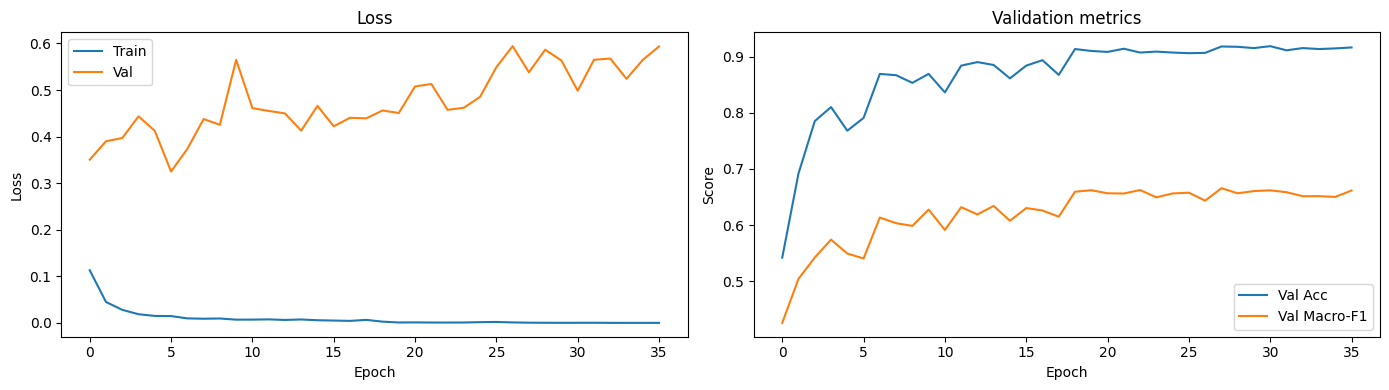

[CELL 7] ✓ Saved curves -> /kaggle/working/stage2_v6_curves.png


In [8]:
# ================== CELL 7: TRAINING LOOP ==================
def run_eval(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    total_loss = 0.0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            logits = model(imgs)
            loss = criterion3(logits, labels)
            total_loss += loss.item() * imgs.size(0)
            preds = logits.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy().tolist())
            all_labels.extend(labels.cpu().numpy().tolist())
    avg_loss = total_loss / max(1, len(all_labels))
    acc = accuracy_score(all_labels, all_preds) if all_labels else 0.0
    macro_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0) if all_labels else 0.0
    return avg_loss, acc, macro_f1, all_labels, all_preds

print('='*70)
print('[CELL 7] TRAINING START')
print('='*70)

best_val_f1 = -1.0
patience_counter = 0
history = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'val_f1': []}

for epoch in range(CONFIG2['epochs']):
    model3.train()
    epoch_loss = 0.0
    n_seen = 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer3.zero_grad()
        logits = model3(imgs)
        loss = criterion3(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model3.parameters(), 1.0)
        optimizer3.step()
        epoch_loss += loss.item() * imgs.size(0)
        n_seen += imgs.size(0)
    avg_train_loss = epoch_loss / max(1, n_seen)

    val_loss, val_acc, val_f1, _, _ = run_eval(model3, val_loader)
    scheduler3.step(val_f1)

    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)

    current_lr = optimizer3.param_groups[0]['lr']
    msg = (f'Epoch {epoch+1:03d}/{CONFIG2["epochs"]} | '
           f'train_loss={avg_train_loss:.4f} | val_loss={val_loss:.4f} | '
           f'val_acc={val_acc:.4f} | val_macro_f1={val_f1:.4f} | lr={current_lr:.2e}')

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        patience_counter = 0
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model3.state_dict(),
            'optimizer_state_dict': optimizer3.state_dict(),
            'val_macro_f1': best_val_f1,
            'classes': CLASSES,
            'class_colors': CLASS_COLORS,
            'crop_pad': CONFIG2['crop_pad'],
            'img_size': CONFIG2['img_size'],
            'norm_mean': _NORM_MEAN,
            'norm_std': _NORM_STD,
            'healthy_iou_thresh': CONFIG2['healthy_iou_thresh'],
        }, '/kaggle/working/stage2_disease_best.pth')
        msg += '  ← best ✓ (saved)'
    else:
        patience_counter += 1
        msg += f'  (no improvement, patience {patience_counter}/{CONFIG2["patience"]})'

    print(msg)

    if patience_counter >= CONFIG2['patience']:
        print(f'  ⏹ Early stopping triggered at epoch {epoch+1} '
              f'(best val_macro_f1={best_val_f1:.4f})')
        break

torch.save(model3.state_dict(), '/kaggle/working/stage2_disease_final.pth')
print()
print(f'[CELL 7] ✓ Training complete. Best val_macro_f1 = {best_val_f1:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(history['train_loss'], label='Train'); axes[0].plot(history['val_loss'], label='Val')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].set_title('Loss'); axes[0].legend()
axes[1].plot(history['val_acc'], label='Val Acc'); axes[1].plot(history['val_f1'], label='Val Macro-F1')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Score'); axes[1].set_title('Validation metrics'); axes[1].legend()
plt.tight_layout()
plt.savefig('/kaggle/working/stage2_v6_curves.png', dpi=120)
plt.show()
print('[CELL 7] ✓ Saved curves -> /kaggle/working/stage2_v6_curves.png')


In [9]:
# ================== CELL 8: TEST SET EVALUATION ==================
print('[CELL 8] Loading best checkpoint for test evaluation...')
_best_ckpt = torch.load('/kaggle/working/stage2_disease_best.pth', map_location=DEVICE)
model3.load_state_dict(_best_ckpt['model_state_dict'])
model3.to(DEVICE).eval()
print(f'  Loaded checkpoint from epoch {_best_ckpt["epoch"]}  '
      f'(val_macro_f1={_best_ckpt["val_macro_f1"]:.4f})')

test_loss, test_acc, test_f1, test_labels, test_preds = run_eval(model3, test_loader)

print()
print('='*70)
print('[CELL 8] TEST SET RESULTS')
print('='*70)
print(f'  Test loss      : {test_loss:.4f}')
print(f'  Test accuracy  : {test_acc:.4f}')
print(f'  Test macro-F1  : {test_f1:.4f}')
print()

_label_order = sorted(CLASSES)
_target_names = [CLASSES[l] for l in _label_order]

print('  Per-class classification report:')
report_str = classification_report(
    test_labels, test_preds, labels=_label_order, target_names=_target_names,
    zero_division=0,
)
print(report_str)

cm = confusion_matrix(test_labels, test_preds, labels=_label_order)
print('  Confusion matrix (rows=true, cols=predicted):')
header = '             ' + ''.join(f'{n[:10]:>12s}' for n in _target_names)
print(header)
for i, row in enumerate(cm):
    print(f'  {_target_names[i][:10]:>10s} ' + ''.join(f'{v:>12d}' for v in row))

report_dict = classification_report(
    test_labels, test_preds, labels=_label_order, target_names=_target_names,
    zero_division=0, output_dict=True,
)
report_dict['confusion_matrix'] = cm.tolist()
report_dict['test_loss'] = test_loss
report_dict['test_accuracy'] = test_acc
report_dict['test_macro_f1'] = test_f1

with open('/kaggle/working/stage2_v6_test_report.json', 'w') as f:
    json.dump(report_dict, f, indent=2)

print()
print('[CELL 8] ✓ Saved -> /kaggle/working/stage2_v6_test_report.json')


[CELL 8] Loading best checkpoint for test evaluation...
  Loaded checkpoint from epoch 28  (val_macro_f1=0.6657)

[CELL 8] TEST SET RESULTS
  Test loss      : 0.4829
  Test accuracy  : 0.9119
  Test macro-F1  : 0.6432

  Per-class classification report:
                   precision    recall  f1-score   support

          Healthy       0.96      0.96      0.96      1282
         Impacted       0.84      0.99      0.91        88
           Caries       0.83      0.83      0.83       364
Periapical Lesion       0.00      0.00      0.00        21
      Deep Caries       0.51      0.52      0.51        62

         accuracy                           0.91      1817
        macro avg       0.63      0.66      0.64      1817
     weighted avg       0.90      0.91      0.91      1817

  Confusion matrix (rows=true, cols=predicted):
                  Healthy    Impacted      Caries  Periapical  Deep Carie
     Healthy         1235           9          32           0           6
    Impacted    

In [10]:
# ================== CELL 9: SAVE FINAL ARTIFACTS + QUICK SANITY CHECK ==================
def classify_tooth_crop(pil_crop, model, device):
    x = _eval_tfm(pil_crop).unsqueeze(0).to(device)
    with torch.no_grad():
        logits = model(x)
        probs = torch.softmax(logits, dim=1).cpu().numpy()[0]
    pred_label = int(probs.argmax())
    return {
        'label': pred_label,
        'label_name': CLASSES[pred_label],
        'confidence': float(probs[pred_label]),
        'probs': {CLASSES[i]: float(probs[i]) for i in range(NUM_CLASSES)},
    }

print('[CELL 9] Quick sanity check — 8 random test crops (predicted vs. ground truth):')
print('-' * 70)
random.seed(123)
_sample_idx = random.sample(range(len(test_samples)), min(8, len(test_samples)))
_correct = 0
for i in _sample_idx:
    s = test_samples[i]
    img = Image.open(s['fpath']).convert('RGB')
    x1, y1, x2, y2 = s['box']
    pad = CONFIG2['crop_pad']
    iw, ih = img.size
    cx1, cy1 = max(0, int(x1)-pad), max(0, int(y1)-pad)
    cx2, cy2 = min(iw, int(x2)+pad), min(ih, int(y2)+pad)
    crop = img.crop((cx1, cy1, cx2, cy2))
    result = classify_tooth_crop(crop, model3, DEVICE)
    true_name = CLASSES[s['label']]
    match = '✓' if result['label'] == s['label'] else '✗'
    if result['label'] == s['label']:
        _correct += 1
    print(f"  {match}  true={true_name:<18s} pred={result['label_name']:<18s} "
          f"conf={result['confidence']:.3f}  file={os.path.basename(s['fpath'])}")

print('-' * 70)
print(f'  Sanity-check accuracy on this mini-sample: {_correct}/{len(_sample_idx)}')

print()
print('[CELL 9] Final files in /kaggle/working:')
for fname in sorted(os.listdir('/kaggle/working')):
    fpath = os.path.join('/kaggle/working', fname)
    if os.path.isfile(fpath):
        size_kb = os.path.getsize(fpath) / 1024
        print(f'    {fname:<40s} {size_kb:>10.1f} KB')

print()
print('[CELL 9] ✓ STAGE 2 v6 COMPLETE.')
print(f'  Best model  : /kaggle/working/stage2_disease_best.pth')
print(f'  Final model : /kaggle/working/stage2_disease_final.pth')
print(f'  Classes     : {CLASSES}')
print('  -> Use stage2_disease_best.pth as the Stage 2 dataset input for the Stage 3 pipeline notebook.')


[CELL 9] Quick sanity check — 8 random test crops (predicted vs. ground truth):
----------------------------------------------------------------------
  ✗  true=Caries             pred=Healthy            conf=0.628  file=train_534.png
  ✓  true=Healthy            pred=Healthy            conf=0.799  file=train_518.png
  ✗  true=Caries             pred=Deep Caries        conf=0.746  file=train_578.png
  ✓  true=Healthy            pred=Healthy            conf=0.999  file=train_288.png
  ✓  true=Healthy            pred=Healthy            conf=0.989  file=train_486.png
  ✓  true=Healthy            pred=Healthy            conf=0.922  file=train_38.png
  ✓  true=Caries             pred=Caries             conf=0.998  file=train_261.png
  ✓  true=Healthy            pred=Healthy            conf=0.958  file=train_434.png
----------------------------------------------------------------------
  Sanity-check accuracy on this mini-sample: 6/8

[CELL 9] Final files in /kaggle/working:
    stage2_disea